# Retrieval ladder

One dense retriever is where most RAG systems start and where many of them stop. This notebook builds a ladder of retrievers over your corpus pages, from dense search to BM25, fusion, reranking, and query expansion, and scores every rung against your own eval cases so the choice is a number, not a feeling.

## Learn | Create | Grow

### Learn
A ladder of retrievers on the same questions: dense, BM25 written from scratch, fusion with RRF, a cross-encoder reranker, multi-query. What each rung adds and what it costs.


### Create
Eval cases labelled with the pages that hold the evidence, a scored table of hit rate and MRR per rung over your corpus, and a permission filter that runs inside the query rather than after it.



### Grow
Ship the cheapest rung that clears your bar and write down which question type needs the expensive one. In production the bar is measured on every change, not once.


**Estimated time:** 45 minutes
**Reads:** corpus, vibe_checks
**Writes:** eval_cases, ladder

## Setup

The corpus is the directory of markdown pages rendered from your workspace. Two pages are left out of the index: the wiki, because it is an index of the others, and the vibe checks page, because it is the answer key. Every retriever below runs over the same chunks, so the comparison is fair.

In [1]:
import math, os, re, time
from collections import Counter

os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
import pandas as pd
from langchain_core.documents import Document
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

from helpers.config import KEY, LLM_BASE, LLM_MODEL, EMBED_BASE, EMBED_MODEL, COHERE_KEY, require, budget
from helpers import workspace as ws, ui
from helpers.llm import chat_model, embeddings_model

require("OPENAI_API_KEY")
CORPUS_DIR = ws.load_path("corpus")
PAGES = {}
for p in sorted(CORPUS_DIR.rglob("*.md")):
    rel = p.relative_to(CORPUS_DIR).as_posix()
    if not rel.startswith("wiki/") and rel != "vibe_checks.md":
        PAGES[rel] = p.read_text(encoding="utf-8")

splitter = RecursiveCharacterTextSplitter(chunk_size=800, chunk_overlap=120)
DOCS = splitter.split_documents([Document(page_content=t, metadata={"page": n}) for n, t in PAGES.items()])
for i, d in enumerate(DOCS):
    d.metadata["chunk"] = i
CHUNKS = [d.page_content for d in DOCS]
PAGE_OF = [d.metadata["page"] for d in DOCS]
K = 4

VIBES = ws.load("vibe_checks")
llm = chat_model(temperature=1)
print(f"✅ {len(PAGES)} pages -> {len(CHUNKS)} chunks; {len(VIBES)} vibe checks; chat {LLM_MODEL}; embeddings {EMBED_MODEL}")

✅ 24 pages -> 59 chunks; 5 vibe checks; chat gpt-5.5; embeddings text-embedding-3-large


You should see a ✅ line with a page count above five, a chunk count above twenty, and at least five vibe checks. Stop here if the page count is zero: the corpus has not been built yet, so run the RAG notebook first or let the seed carry it.

# Learn


## Task 1 of 5 — Label the evidence

A retrieval score needs an answer key: for each question, which pages hold the evidence. Labelling pages rather than chunks keeps the labels valid when you change the chunk size later. The model proposes the pages from a one-line digest of each; you correct it. A question outside the product gets no page, and the scorer skips it.

In [2]:
from typing import List
from pydantic import BaseModel


class Evidence(BaseModel):
    pages: List[str]


DIGEST = "\n".join(f"- {name}: {' '.join(text.split())[:240]}" for name, text in PAGES.items())
labeller = llm.with_structured_output(Evidence)


def label_pages(question: str, reference: str) -> list:
    """The pages a good answer draws on, as the model reads the digest. Edit the result by hand."""
    picked = labeller.invoke(
        "Which of these pages hold the evidence a good answer to the question needs? "
        "Return only page names from the list, or an empty list if none of them does.\n\n"
        f"PAGES:\n{DIGEST}\n\nQuestion: {question}\nA good answer includes: {reference}")
    return [p for p in picked.pages if p in PAGES]


CASES = []
for v in ui.track(VIBES, "labelling"):
    CASES.append({"id": v["id"], "question": v["input"], "reference": v["expected"],
                  "pages": label_pages(v["input"], v["expected"])})
ws.save("eval_cases", CASES)
for c in CASES:
    print(f"{c['id']}  {c['question'][:58]:<58}  {c['pages'] or 'no evidence'}")

✅ wrote eval_cases → workspace/retrieval/eval_cases.jsonl (5 rows)
v01  My VPN connects but I cannot reach staging.                 no evidence
v02  How do I get access to the analytics warehouse?             ['charter.md', 'prompts/meta-prompt-generate.md', 'prompts/structured-output.md']
v03  uv sync removed a package I installed.                      no evidence
v04  Can you reset my colleague's MFA for me?                    ['charter.md']
v05  What is the capital of Peru?                                no evidence


You should see a ✅ line and one row per vibe check with the pages it names. The out-of-scope check should say no evidence. Stop here if every row names the same page: the digest is too short to tell pages apart, so raise the 240 to 500 and rerun.

## Task 2 of 5 — Dense and sparse

Dense search finds text with a similar meaning. It blurs exact tokens: a setting name, an error string, an entitlement id. BM25 scores by term overlap, so it finds those. The from-scratch class below is the whole algorithm: term frequency that saturates, weighted by how rare the term is, normalised by document length. The library version is one line and gives the same ranking.

In [3]:
TOKEN = re.compile(r"[a-z0-9][a-z0-9.-]*")


def tokenize(text: str) -> list:
    return TOKEN.findall(text.lower())


class BM25:
    """Term frequency that saturates, weighted by rarity, normalised by length."""

    def __init__(self, texts, k1=1.5, b=0.75):
        self.docs = [tokenize(t) for t in texts]
        self.N, self.k1, self.b = len(self.docs), k1, b
        self.avgdl = sum(len(d) for d in self.docs) / self.N
        self.df = Counter(t for d in self.docs for t in set(d))
        self.tf = [Counter(d) for d in self.docs]

    def idf(self, term: str) -> float:
        n = self.df.get(term, 0)
        return math.log((self.N - n + 0.5) / (n + 0.5) + 1)

    def score(self, query: str, i: int) -> float:
        dl, s = len(self.docs[i]), 0.0
        for t in tokenize(query):
            f = self.tf[i].get(t, 0)
            if f:
                s += self.idf(t) * f * (self.k1 + 1) / (f + self.k1 * (1 - self.b + self.b * dl / self.avgdl))
        return s

    def search(self, query: str, k: int = K) -> list:
        return sorted(range(self.N), key=lambda i: self.score(query, i), reverse=True)[:k]


from rank_bm25 import BM25Okapi   # the same formula, vectorised

scratch = BM25(CHUNKS)
library = BM25Okapi([tokenize(c) for c in CHUNKS])


def bm25_search(query: str, k: int = K) -> list:
    scores = library.get_scores(tokenize(query))
    return sorted(range(len(CHUNKS)), key=lambda i: scores[i], reverse=True)[:k]


HARD = CASES[0]["question"]
print("Q:", HARD)
print("scratch:", [PAGE_OF[i] for i in scratch.search(HARD)])
print("library:", [PAGE_OF[i] for i in bm25_search(HARD)])

Q: My VPN connects but I cannot reach staging.
scratch: ['transcripts/t05.md', 'transcripts/t01.md', 'transcripts/t05.md', 'transcripts/t01.md']
library: ['transcripts/t05.md', 'transcripts/t01.md', 'transcripts/t03.md', 'charter.md']


In [4]:
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams

embeddings = embeddings_model()
qdrant = QdrantClient(":memory:")   # disposable: the ladder re-embeds its own chunks so every rung sees the same ones
dim = len(embeddings.embed_query("dimension probe"))
qdrant.create_collection("ladder", vectors_config=VectorParams(size=dim, distance=Distance.COSINE))
store = QdrantVectorStore(client=qdrant, collection_name="ladder", embedding=embeddings)
with ui.spinner("embedding the chunks"):
    store.add_documents(DOCS)


def dense_search(query: str, k: int = K) -> list:
    return [d.metadata["chunk"] for d, _ in store.similarity_search_with_score(query, k=k)]


print("dense: ", [PAGE_OF[i] for i in dense_search(HARD)])
print("bm25:  ", [PAGE_OF[i] for i in bm25_search(HARD)])

dense:  ['transcripts/t05.md', 'transcripts/t05.md', 'transcripts/t01.md', 'prompts/persona-patient.md']
bm25:   ['transcripts/t05.md', 'transcripts/t01.md', 'transcripts/t03.md', 'charter.md']


You should see the same page order from the scratch and library BM25, then the dense and BM25 page lists for one question, usually different. Stop here if the scratch and library orders disagree: the tokenizer differs between them, so check `tokenize` is used for both.

### ❓ Question
Pick the question where dense and BM25 disagree most. Which words in the question did BM25 lock onto, and which meaning did dense search chase instead?

Answer:

## Task 3 of 5 — Fuse, rerank, expand

Dense and BM25 win on different questions, so let both vote. Reciprocal rank fusion adds `1 / (60 + rank)` from each list; a chunk near the top of both wins with no score normalisation. A cross-encoder then reads the question and each candidate together and reorders the shortlist. Query expansion asks the question three more ways before fusing. Each rung costs more than the one below it.

In [5]:
def rrf(rankings: list, k: int = 60) -> list:
    """Fuse ranked lists of chunk ids: each list adds 1/(k + rank) to a chunk's score."""
    scores = {}
    for ranking in rankings:
        for rank, i in enumerate(ranking, 1):
            scores[i] = scores.get(i, 0.0) + 1 / (k + rank)
    return sorted(scores, key=scores.get, reverse=True)


N_CANDIDATES = 12


def hybrid_search(query: str, k: int = K) -> list:
    return rrf([dense_search(query, N_CANDIDATES), bm25_search(query, N_CANDIDATES)])[:k]


print("hybrid:", [PAGE_OF[i] for i in hybrid_search(HARD)])

hybrid: ['transcripts/t05.md', 'transcripts/t05.md', 'transcripts/t05.md', 'transcripts/t01.md']


In [6]:
from sentence_transformers import CrossEncoder

cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")   # downloaded once, then cached locally


def rerank(query: str, candidates: list, k: int = K) -> list:
    scores = cross_encoder.predict([(query, CHUNKS[i]) for i in candidates])
    return [i for i, _ in sorted(zip(candidates, scores), key=lambda x: -x[1])[:k]]


def rerank_search(query: str, k: int = K) -> list:
    return rerank(query, hybrid_search(query, N_CANDIDATES), k)


def text_of(message) -> str:
    return message.content if isinstance(message.content, str) else str(message.content)


def expand(question: str, n: int = 3) -> list:
    """The question plus n short rewrites of it, one per line."""
    reply = text_of(llm.invoke(f"Write {n} short, distinct search queries that would find evidence for this question. "
                               f"One per line, no numbering.\n\n{question}"))
    extra = [line.strip(" -\t") for line in reply.splitlines() if line.strip()]
    return [question, *extra][: n + 1]


def multi_query_search(query: str, k: int = K) -> list:
    fused = rrf([hybrid_search(q, N_CANDIDATES) for q in expand(query)])
    return rerank(query, fused[:N_CANDIDATES], k)


RETRIEVERS = {"dense": dense_search, "bm25": bm25_search, "hybrid_rrf": hybrid_search,
              "cross_encoder": rerank_search, "multi_query": multi_query_search}

if COHERE_KEY:   # an optional rung: a hosted reranker instead of the local cross-encoder
    from helpers.config import COHERE_BASE
    import httpx as _httpx
    _is_apim_rerank = COHERE_BASE and "azure-api.net" in COHERE_BASE

    def cohere_search(query: str, k: int = K) -> list:
        candidates = hybrid_search(query, N_CANDIDATES)
        docs = [CHUNKS[i] for i in candidates]
        if _is_apim_rerank:
            url = COHERE_BASE.rstrip("/") + "/rerank"
            r = _httpx.post(url, params={"subscription-key": COHERE_KEY},
                            json={"model": "Cohere-rerank-v4.0-pro", "query": query,
                                  "documents": docs, "top_n": k}, timeout=30)
            r.raise_for_status()
            results = r.json()["results"]
            return [candidates[item["index"]] for item in results]
        import cohere
        co = cohere.ClientV2(api_key=COHERE_KEY)
        resp = co.rerank(model="rerank-v3.5", query=query, documents=docs, top_n=k)
        return [candidates[r.index] for r in resp.results]

    RETRIEVERS["cohere_rerank"] = cohere_search

print("rewrites:", expand(HARD))
for name, search in RETRIEVERS.items():
    print(f"{name:<14}", [PAGE_OF[i] for i in search(HARD)])

rewrites: ['My VPN connects but I cannot reach staging.', 'VPN connected cannot reach staging', 'staging inaccessible over VPN', 'VPN connected but staging timeout']
dense          ['transcripts/t05.md', 'transcripts/t05.md', 'transcripts/t01.md', 'prompts/persona-patient.md']
bm25           ['transcripts/t05.md', 'transcripts/t01.md', 'transcripts/t03.md', 'charter.md']
hybrid_rrf     ['transcripts/t05.md', 'transcripts/t05.md', 'transcripts/t05.md', 'transcripts/t01.md']
cross_encoder  ['transcripts/t05.md', 'transcripts/t01.md', 'transcripts/t05.md', 'transcripts/t01.md']
multi_query    ['transcripts/t05.md', 'transcripts/t01.md', 'transcripts/t05.md', 'transcripts/t01.md']
cohere_rerank  ['prompts/persona-none.md', 'prompts/persona-terse.md', 'transcripts/t01.md', 'prompts/meta-prompt-applied.md']


You should see three rewrites of the question, then one page list per retriever, five or six rows. Stop here if the cross-encoder line raises a download error: the model comes from the Hugging Face hub on first use, so connect once and rerun.

# Create


## Task 4 of 5 — Score the ladder

Two numbers per rung, over the labelled cases. Hit rate: did any of the top `K` chunks come from a labelled page. MRR: one over the rank of the first such chunk, averaged, so a hit at rank 1 scores 1 and a hit at rank 4 scores 0.25. Latency is in the table too, because the top rungs pay for their gains in seconds.

In [7]:
def score_case(case: dict, ranked: list) -> tuple:
    """(hit, reciprocal rank) for one ranked list against the case's labelled pages."""
    for rank, i in enumerate(ranked, 1):
        if PAGE_OF[i] in case["pages"]:
            return 1.0, 1.0 / rank
    return 0.0, 0.0


SCORED = [c for c in CASES if c["pages"]][:budget(len(CASES), 3)]
LADDER, PER_CASE = [], []
for name, search in RETRIEVERS.items():
    hits, rrs, t0 = [], [], time.time()
    for c in ui.track(SCORED, name):
        hit, rr = score_case(c, search(c["question"], K))
        hits.append(hit); rrs.append(rr)
        PER_CASE.append({"case": c["id"], "retriever": name, "rr": rr})
    LADDER.append({"retriever": name, "hit_rate": round(sum(hits) / len(hits), 3), "mrr": round(sum(rrs) / len(rrs), 3),
                   "k": K, "cases": len(SCORED), "ms_per_query": round(1000 * (time.time() - t0) / len(SCORED))})
ws.save("ladder", LADDER)
ladder_df = pd.DataFrame(LADDER).set_index("retriever")
ui.table(ladder_df, title=f"the ladder at k={K} over {len(SCORED)} cases")

✅ wrote ladder → workspace/retrieval/ladder.csv (6 rows)


                  the ladder at k=4 over 2 cases                   
┏━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━┓
┃ retriever     ┃ hit_rate ┃   mrr ┃     k ┃ cases ┃ ms_per_query ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━┩
│ dense         │    0.000 │ 0.000 │ 4.000 │ 2.000 │      342.000 │
│ bm25          │    0.000 │ 0.000 │ 4.000 │ 2.000 │       15.000 │
│ hybrid_rrf    │    0.000 │ 0.000 │ 4.000 │ 2.000 │      413.000 │
│ cross_encoder │    0.000 │ 0.000 │ 4.000 │ 2.000 │     1039.000 │
│ multi_query   │    0.000 │ 0.000 │ 4.000 │ 2.000 │     3862.000 │
│ cohere_rerank │    0.000 │ 0.000 │ 4.000 │ 2.000 │     1076.000 │
└───────────────┴──────────┴───────┴───────┴───────┴──────────────┘

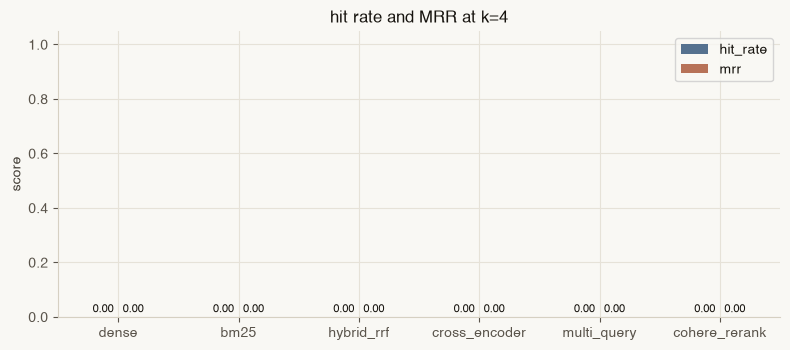

                             reciprocal rank per case                             
┏━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ case ┃ dense ┃ bm25 ┃ hybrid_rrf ┃ cross_encoder ┃ multi_query ┃ cohere_rerank ┃
┡━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ v02  │  0.00 │ 0.00 │       0.00 │          0.00 │        0.00 │          0.00 │
│ v04  │  0.00 │ 0.00 │       0.00 │          0.00 │        0.00 │          0.00 │
└──────┴───────┴──────┴────────────┴───────────────┴─────────────┴───────────────┘

In [8]:
import matplotlib.pyplot as plt
from helpers.brand import matplotlib_style

plt.rcParams.update(matplotlib_style())
ax = ladder_df[["hit_rate", "mrr"]].plot.bar(figsize=(8, 3.6), rot=0)
ax.set_ylim(0, 1.05); ax.set_ylabel("score"); ax.set_xlabel(""); ax.set_title(f"hit rate and MRR at k={K}")
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", padding=2, fontsize=8)
plt.tight_layout(); plt.show()

rr_matrix = pd.DataFrame(PER_CASE).pivot(index="case", columns="retriever", values="rr")
ui.table(rr_matrix[list(RETRIEVERS)], title="reciprocal rank per case", float_fmt="{:.2f}")

You should see a ✅ line, a table with one row per retriever, a bar chart, and a per-case matrix of reciprocal ranks. Stop here if every rung scores 1.0 on everything: the corpus is too small to separate them, so add your own pages before you draw a conclusion.

### ❓ Question
Read the per-case matrix, not the averages. Which case separates the rungs, and would you pay the top rung's latency for that one case?

Answer:

## Task 5 of 5 — Filter before you rank

An index that holds pages with different access rules turns retrieval into an authorisation bypass: the model quotes a page to someone who could never open it. Tag every chunk with a group, a stand-in for a real access list: transcripts belong to the helpdesk, everything else to everyone. Then build the dense retriever twice for a user in everyone. The first ranks and then drops what the user may not read. The second passes the permission into the query, so Qdrant never scores a forbidden chunk. Dropping after ranking looks the same in a demo and fails in production: the match itself leaks, through counts, gaps, and rank positions.


In [9]:
from qdrant_client.models import FieldCondition, Filter, MatchAny, MatchValue


def group_of(page: str) -> str:
    """A stand-in for a real access list: transcripts belong to the helpdesk, everything else to everyone."""
    return "helpdesk" if page.startswith("transcripts/") else "everyone"


for group in ("helpdesk", "everyone"):   # tag the chunks already in the store, page by page
    members = [p for p in PAGES if group_of(p) == group]
    if members:
        qdrant.set_payload("ladder", payload={"group": group}, key="metadata",
                           points=Filter(must=[FieldCondition(key="metadata.page", match=MatchAny(any=members))]))
helpdesk_only = Filter(must=[FieldCondition(key="metadata.group", match=MatchValue(value="helpdesk"))])
print(f"{qdrant.count('ladder', count_filter=helpdesk_only).count} of {len(CHUNKS)} chunks are helpdesk-only")

USER_GROUP = "everyone"


def post_filter(query: str, k: int = K) -> tuple:
    """(a) rank first, then drop what the user may not read. Returns (everything ranked, what survived)."""
    ranked = store.similarity_search(query, k=k)
    return ranked, [d for d in ranked if d.metadata.get("group") == USER_GROUP]


allowed = Filter(must=[FieldCondition(key="metadata.group", match=MatchValue(value=USER_GROUP))])
pre_filtered = store.as_retriever(search_kwargs={"k": K, "filter": allowed})   # (b) the permission travels with the query

leaky = next((c["question"] for c in SCORED if len(post_filter(c["question"])[1]) < K), SCORED[0]["question"])
ranked, kept = post_filter(leaky)
print(f"\nQ: {leaky}\nuser group: {USER_GROUP}\n")
print("(a) rank, then drop:")
for d in ranked:
    ok = d.metadata.get("group") == USER_GROUP
    print(f"    {'kept   ' if ok else 'DROPPED'} {d.metadata['page']}  [{d.metadata.get('group')}]")
print(f"    returned {len(kept)} of {K}: the dropped pages still ranked, and the gap says so")
print("(b) filter in the query, then rank:")
allowed_docs = pre_filtered.invoke(leaky)
for d in allowed_docs:
    print(f"    kept    {d.metadata['page']}  [{d.metadata.get('group')}]")
print(f"    returned {len(allowed_docs)} of {K}, every one readable by {USER_GROUP}")


23 of 59 chunks are helpdesk-only

Q: How do I get access to the analytics warehouse?
user group: everyone

(a) rank, then drop:
    DROPPED transcripts/t06.md  [helpdesk]
    DROPPED transcripts/t02.md  [helpdesk]
    DROPPED transcripts/t02.md  [helpdesk]
    DROPPED transcripts/t06.md  [helpdesk]
    returned 0 of 4: the dropped pages still ranked, and the gap says so
(b) filter in the query, then rank:
    kept    prompts/persona-patient.md  [everyone]
    kept    prompts/meta-prompt-applied.md  [everyone]
    kept    prompts/persona-patient.md  [everyone]
    kept    prompts/stacked.md  [everyone]
    returned 4 of 4, every one readable by everyone


You should see the helpdesk chunk count, then one question with its ranked list marked kept or dropped and fewer than four kept, then four kept pages from the filtered query. Stop here if nothing is dropped for any question: no transcript ranked, so ask about a conversation from your transcripts.


### ❓ Question
In (a) the short list leaks: what does a user in everyone learn from the count alone, and from the rank a permitted page lands at? Does (b) leak anything as written, and what would you have to display, a total match count, a score, a rank across all groups, before it did?

Answer:


## Your turn

Write one question over your corpus where exactly one retriever gets the right page at rank 1. Label its pages, run it through every rung, and write one sentence on why that rung won. If you cannot find such a question, that is a finding too: dense search is enough for this corpus.

In [10]:
MY_CASE = {"id": "mine", "question": "", "pages": []}   # fill in a question and the pages that answer it

if MY_CASE["question"] and MY_CASE["pages"]:
    for name, search in RETRIEVERS.items():
        ranked = search(MY_CASE["question"], K)
        hit, rr = score_case(MY_CASE, ranked)
        print(f"{name:<14} rr={rr:.2f}  {[PAGE_OF[i] for i in ranked]}")
else:
    print("fill in MY_CASE above, then rerun")

fill in MY_CASE above, then rerun


# Grow


## From prototype to production

| What we built | Production equivalent |
|---|---|
| Pages labelled by a model, corrected by hand | Labels grown from user feedback and reviewed samples |
| An in-memory index rebuilt each run | A persistent index with incremental updates |
| One `K` and one candidate pool per rung | Settings swept per rung against the eval set |
| A local cross-encoder on twelve candidates | A served reranker with a latency budget |
| One ladder for every question | A router that sends easy questions down the cheap path |
| Hit rate and MRR in a table | The same metrics tracked per release, gated |

## Responsible controls

- A labelled eval set that grows with every question type users actually ask.
- Latency per rung measured and budgeted before a rung ships.
- Reranker and embedding model versions pinned and recorded with results.


## Grow further

- Search small, return big: retrieve chunks, then hand the model the whole page each chunk came from, and score whether answers improve.
- Write a router: classify each question as exact-token, paraphrase, or broad, send it to one rung, and match the top rung's MRR at lower average latency.
- Cache the expensive parts, embeddings, rewrites, and rerank scores, keyed by the question, and measure how much latency the cache removes on a second run.